<a href="https://colab.research.google.com/github/kalvii631/Machine-learning/blob/main/EXP09scenario1_user_based_cf_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 1 – User-Based Collaborative Filtering


## Step 1: Import Required Python Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the MovieLens Dataset

In [20]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')

print('Ratings shape:', ratings.shape)
print('Movies shape :', movies.shape)
ratings.head()

Ratings shape: (100836, 4)
Movies shape : (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Step 3: Data Inspection & Preprocessing

In [21]:
print('Null values:\n', ratings.isnull().sum())
print('\nStatistics:\n', ratings.describe())
print('\nUnique users :', ratings['userId'].nunique())
print('Unique movies:', ratings['movieId'].nunique())

Null values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Statistics:
               userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09

Unique users : 610
Unique movies: 9724


In [22]:
data = ratings.merge(movies[['movieId', 'title']], on='movieId')

active_users  = data['userId'].value_counts()
active_movies = data['movieId'].value_counts()

data = data[
    data['userId'].isin(active_users[active_users   >= 20].index) &
    data['movieId'].isin(active_movies[active_movies >= 10].index)
]

print('Filtered shape:', data.shape)
print('Users :', data['userId'].nunique())
print('Movies:', data['movieId'].nunique())

Filtered shape: (81116, 5)
Users : 610
Movies: 2269


## Step 4: Create User-Item Matrix

In [23]:
user_item = data.pivot_table(index='userId', columns='title', values='rating')

print('User-Item Matrix shape:', user_item.shape)
user_item.iloc[:5, :5]

User-Item Matrix shape: (610, 2269)


title,"'burbs, The (1989)",(500) Days of Summer (2009),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),"10,000 BC (2008)"
userId,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


## Step 5: Handle Missing Values

In [24]:
total    = user_item.shape[0] * user_item.shape[1]
missing  = user_item.isnull().sum().sum()
sparsity = (missing / total) * 100

print(f'Total cells  : {total:,}')
print(f'Missing cells: {missing:,}')
print(f'Sparsity     : {sparsity:.2f}%')

user_item_filled = user_item.fillna(0)

Total cells  : 1,384,090
Missing cells: 1,302,974
Sparsity     : 94.14%


## Step 6: Compute Cosine Similarity Between Users

In [25]:
user_sim = pd.DataFrame(
    cosine_similarity(user_item_filled),
    index=user_item_filled.index,
    columns=user_item_filled.index
)

print('Similarity Matrix shape:', user_sim.shape)
user_sim.iloc[:5, :5]

Similarity Matrix shape: (610, 610)


userId,1,2,3,4,5
userId,,,,,
1,1.000000,0.029977,0.115634,0.220630,0.134869
2,0.029977,1.000000,0.000000,0.004256,0.017471
3,0.115634,0.000000,1.000000,0.004532,0.009302
4,0.220630,0.004256,0.004532,1.000000,0.139754
5,0.134869,0.017471,0.009302,0.139754,1.000000


## Step 7: Identify Top-N Similar Users

In [26]:
def get_similar_users(user_id, sim_df, n=10):
    return sim_df[user_id].drop(user_id).nlargest(n)

TARGET = user_item_filled.index[0]
print(f'Top 10 users similar to User {TARGET}:')
print(get_similar_users(TARGET, user_sim))

Top 10 users similar to User 1:
userId
368    0.393441
313    0.386130
91     0.380619
266    0.379847
57     0.374995
288    0.374261
217    0.372970
19     0.370308
469    0.368074
599    0.366603
Name: 1, dtype: float64


## Step 8: Predict Ratings for Unseen Movies

In [27]:
def predict_rating(user_id, movie, matrix, sim_df):
    if movie not in matrix.columns or user_id not in matrix.index:
        return np.nan
    similar = get_similar_users(user_id, sim_df)
    valid   = [u for u in similar.index if u in matrix.index]
    r       = matrix.loc[valid, movie]
    s       = similar[valid]
    mask    = r != 0
    if mask.sum() == 0:
        return np.nan
    return np.dot(s[mask], r[mask]) / s[mask].sum()

## Step 9: Generate Top-N Recommendations

In [28]:
def recommend(user_id, matrix, sim_df, top_n=10):
    unrated = matrix.columns[matrix.loc[user_id] == 0]
    preds   = {m: predict_rating(user_id, m, matrix, sim_df) for m in unrated}
    preds   = {m: v for m, v in preds.items() if not np.isnan(v)}
    return sorted(preds.items(), key=lambda x: x[1], reverse=True)[:top_n]

recs = recommend(TARGET, user_item_filled, user_sim, top_n=10)
rec_df = pd.DataFrame(recs, columns=['Movie', 'Predicted Rating'])
rec_df.index += 1
display(rec_df)

print('\nTop 5 for 3 sample users:')
for uid in user_item_filled.index[:3]:
    print(f'\nUser {uid}:')
    for rank, (movie, score) in enumerate(recommend(uid, user_item_filled, user_sim, top_n=5), 1):
        print(f'  {rank}. {movie[:55]}  ({score:.2f})')

,Movie,Predicted Rating
1,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",5.0
2,"Big Sleep, The (1946)",5.0
3,Doctor Zhivago (1965),5.0
4,Empire Records (1995),5.0
5,In Bruges (2008),5.0
6,Little Big Man (1970),5.0
7,Once Upon a Time in America (1984),5.0
8,Papillon (1973),5.0
9,Paths of Glory (1957),5.0
10,"Ref, The (1994)",5.0



Top 5 for 3 sample users:

User 1:
  1. Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)  (5.00)
  2. Big Sleep, The (1946)  (5.00)
  3. Doctor Zhivago (1965)  (5.00)
  4. Empire Records (1995)  (5.00)
  5. In Bruges (2008)  (5.00)

User 2:
  1. 40-Year-Old Virgin, The (2005)  (5.00)
  2. 8 Mile (2002)  (5.00)
  3. Alien (1979)  (5.00)
  4. Anchorman: The Legend of Ron Burgundy (2004)  (5.00)
  5. Armageddon (1998)  (5.00)

User 3:
  1. Army of Darkness (1993)  (5.00)
  2. One Flew Over the Cuckoo's Nest (1975)  (5.00)
  3. Tommy Boy (1995)  (5.00)
  4. 1984 (Nineteen Eighty-Four) (1984)  (5.00)
  5. 28 Days (2000)  (5.00)


## Step 10: Evaluate – RMSE & MAE

In [29]:
train, test  = train_test_split(data, test_size=0.2, random_state=42)

train_matrix = train.pivot_table(index='userId', columns='title', values='rating').fillna(0)
train_sim    = pd.DataFrame(
    cosine_similarity(train_matrix),
    index=train_matrix.index, columns=train_matrix.index
)

sample = test.sample(200, random_state=42)
actuals, predicted = [], []

for _, row in sample.iterrows():
    p = predict_rating(row['userId'], row['title'], train_matrix, train_sim)
    if not np.isnan(p):
        actuals.append(row['rating'])
        predicted.append(p)

print(f'RMSE             : {np.sqrt(mean_squared_error(actuals, predicted)):.4f}')
print(f'MAE              : {mean_absolute_error(actuals, predicted):.4f}')
print(f'Samples evaluated: {len(actuals)}')

RMSE             : 0.9507
MAE              : 0.7035
Samples evaluated: 188


## Step 11: Precision@K Evaluation

In [12]:
def precision_at_k_user(user_id, k=10, threshold=3.5):
    user_data = data[data['userId'] == user_id]
    if len(user_data) < 5:
        return 0.0

    train_u = user_data.sample(frac=0.8, random_state=42)
    test_u  = user_data.drop(train_u.index)

    train_mat     = train_u.pivot_table(index='userId', columns='title', values='rating').fillna(0)
    other_users   = data[data['userId'] != user_id].pivot_table(index='userId', columns='title', values='rating').fillna(0)
    full_train    = pd.concat([train_mat, other_users]).fillna(0)
    full_train    = full_train[~full_train.index.duplicated(keep='first')]

    sim = pd.DataFrame(
        cosine_similarity(full_train),
        index=full_train.index, columns=full_train.index
    )

    recs         = recommend(user_id, full_train, sim, top_n=k)
    rec_titles   = [r[0] for r in recs]
    ground_truth = set(test_u[test_u['rating'] >= threshold]['title'])

    if not rec_titles or not ground_truth:
        return 0.0

    return sum(1 for m in rec_titles if m in ground_truth) / k

eval_users   = data['userId'].unique()[:30]
K_VALUES     = [5, 10, 20]
prec_results = {k: np.mean([precision_at_k_user(u, k) for u in eval_users]) for k in K_VALUES}

print('Precision@K (avg over 30 users):')
for k, p in prec_results.items():
    print(f'  Precision@{k:2d}: {p:.4f}')

Precision@K (avg over 30 users):
  Precision@ 5: 0.0000
  Precision@10: 0.0067
  Precision@20: 0.0150


## Visualizations

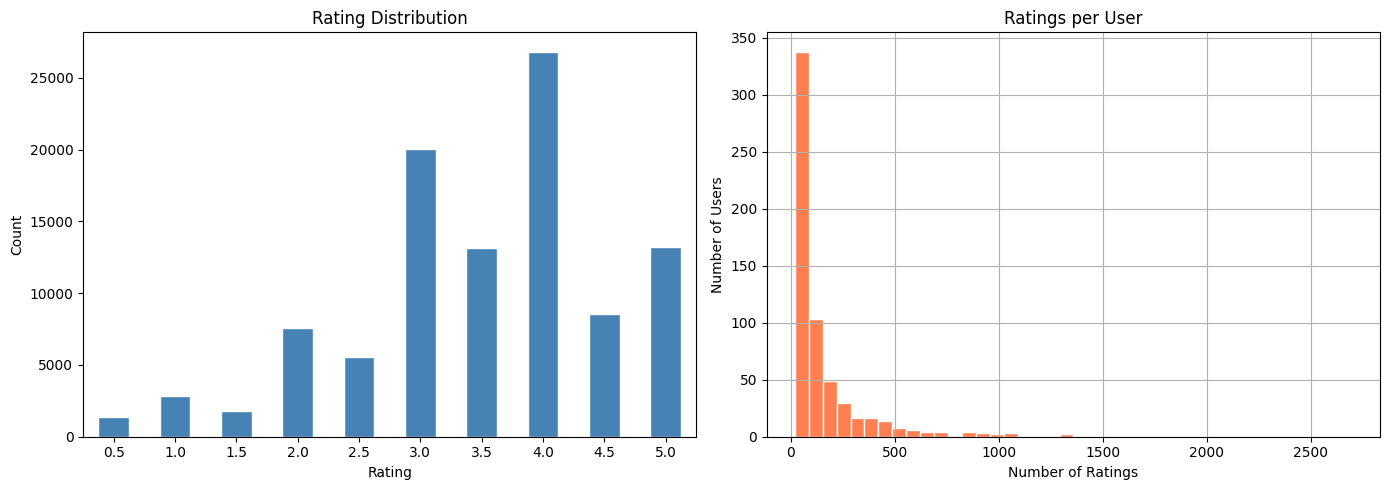

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

ratings.groupby('userId')['rating'].count().hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

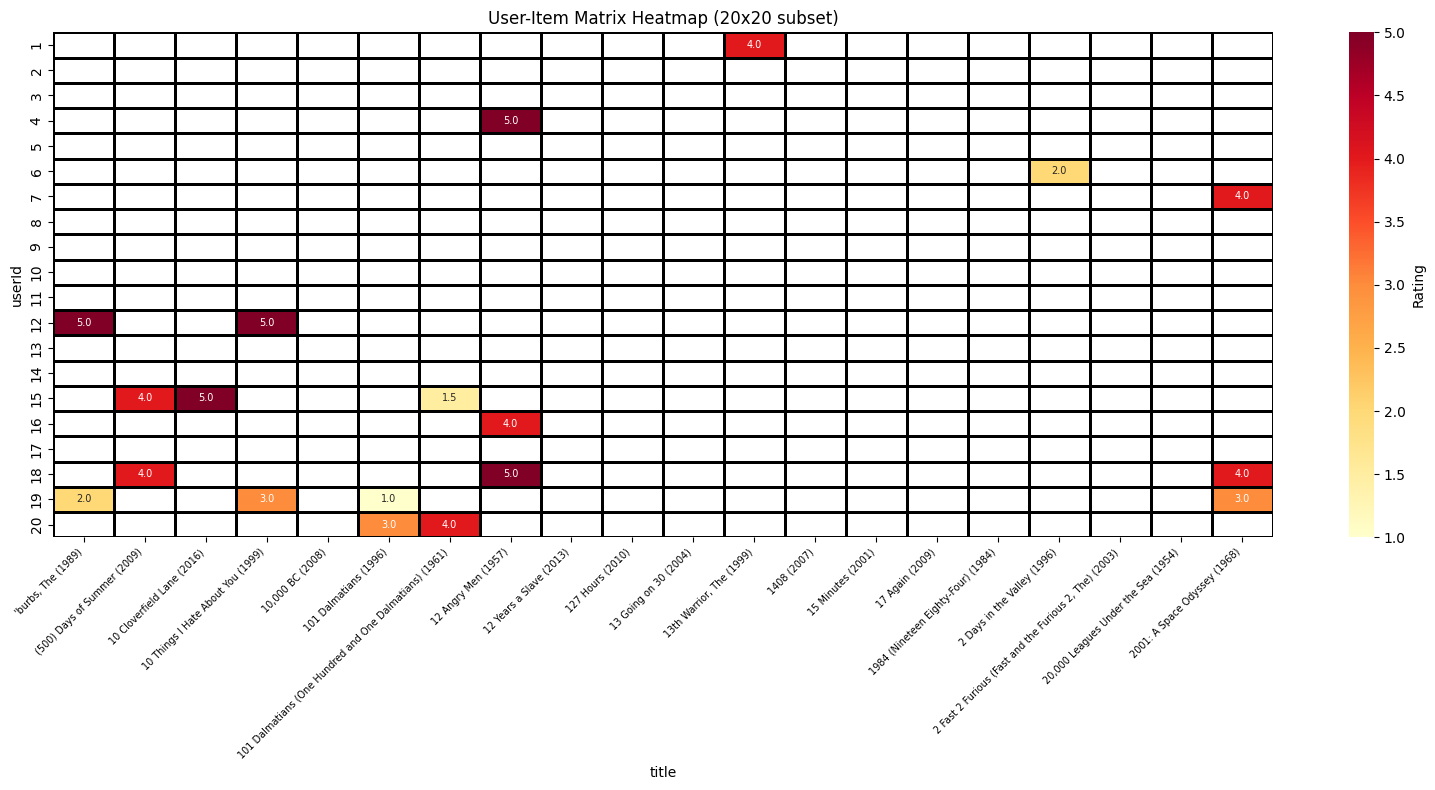

In [14]:
plt.figure(figsize=(16, 8))
sns.heatmap(
    user_item.iloc[:20, :20],
    cmap='YlOrRd',
    linewidths=1, linecolor='black',
    annot=True, fmt='.1f', annot_kws={'size': 7},
    cbar_kws={'label': 'Rating'}
)
plt.title('User-Item Matrix Heatmap (20x20 subset)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('user_item_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

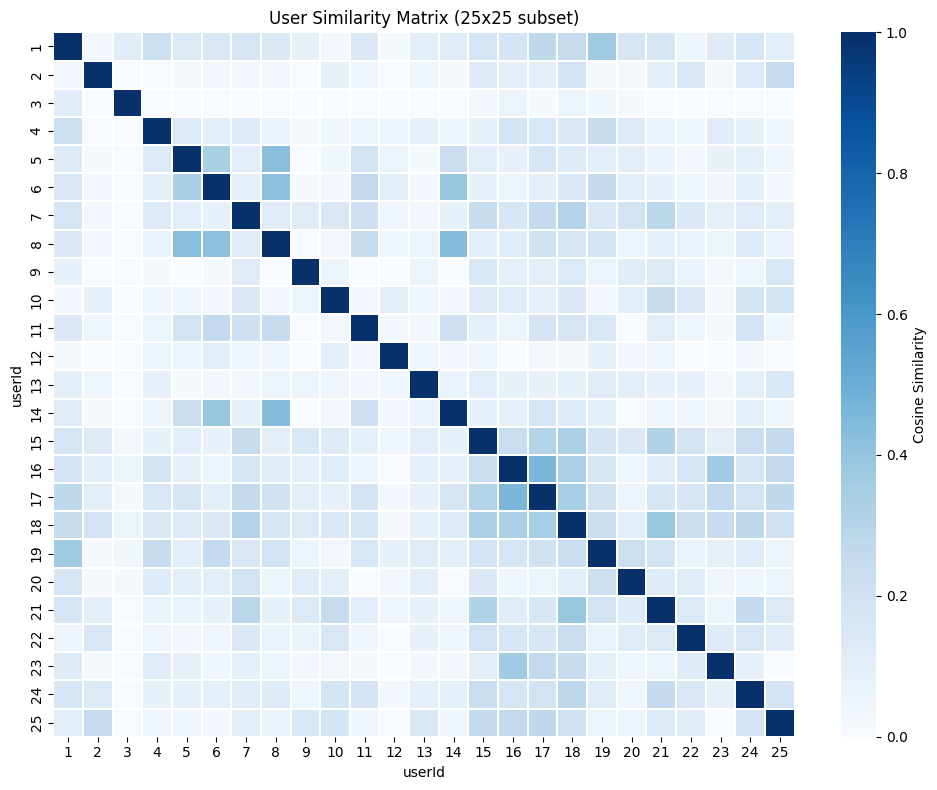

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    user_sim.iloc[:25, :25],
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.2,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('User Similarity Matrix (25x25 subset)')
plt.tight_layout()
plt.savefig('user_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

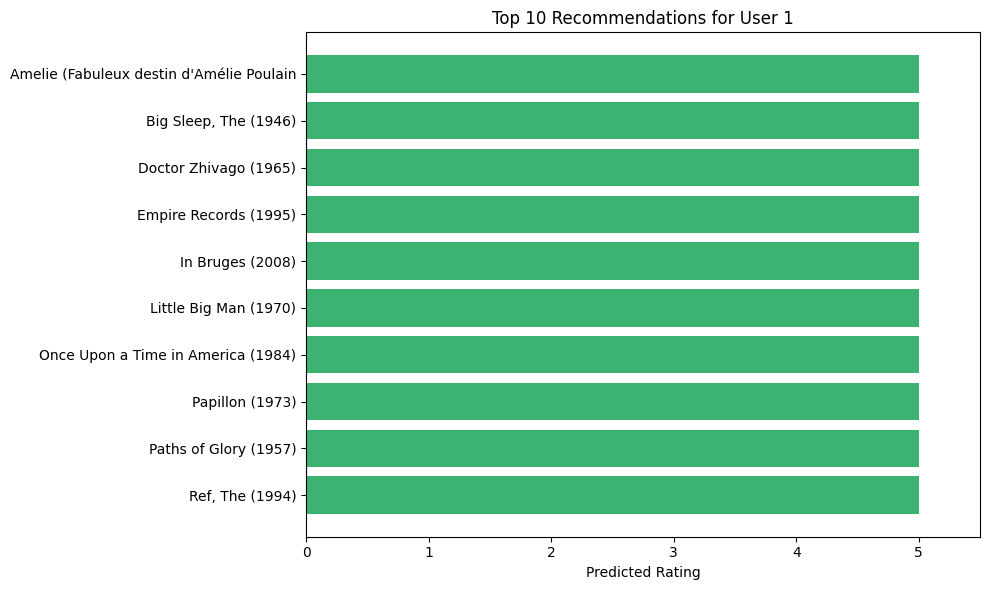

In [16]:
movies_list = [r[0][:40] for r in recs]
scores_list = [r[1]       for r in recs]

plt.figure(figsize=(10, 6))
plt.barh(movies_list[::-1], scores_list[::-1], color='mediumseagreen')
plt.xlabel('Predicted Rating')
plt.title(f'Top 10 Recommendations for User {TARGET}')
plt.xlim(0, 5.5)
plt.tight_layout()
plt.savefig('top_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

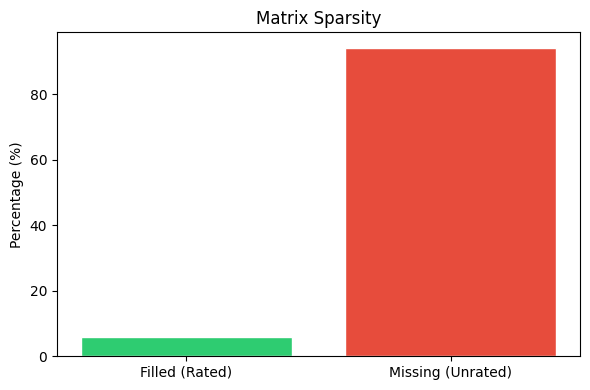

Sparsity: 94.14%


In [17]:
plt.figure(figsize=(6, 4))
plt.bar(
    ['Filled (Rated)', 'Missing (Unrated)'],
    [100 - sparsity, sparsity],
    color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
plt.title('Matrix Sparsity')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.savefig('sparsity_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparsity: {sparsity:.2f}%')

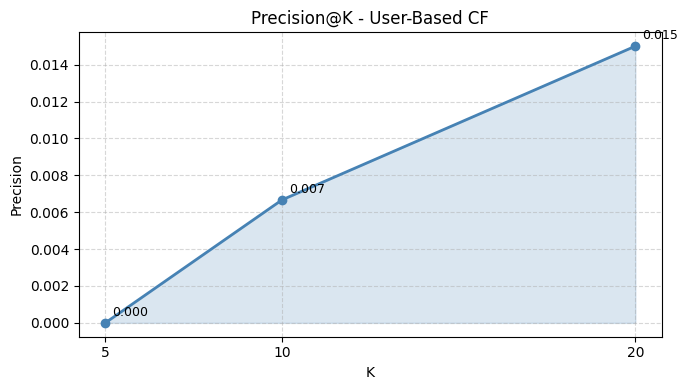

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(list(prec_results.keys()), list(prec_results.values()), marker='o', linewidth=2, color='steelblue')
plt.fill_between(list(prec_results.keys()), list(prec_results.values()), alpha=0.2, color='steelblue')
plt.title('Precision@K - User-Based CF')
plt.xlabel('K')
plt.ylabel('Precision')
plt.xticks(K_VALUES)
plt.grid(True, linestyle='--', alpha=0.5)
for k, p in prec_results.items():
    plt.annotate(f'{p:.3f}', (k, p), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.tight_layout()
plt.savefig('precision_at_k_user.png', dpi=150, bbox_inches='tight')
plt.show()